In [16]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import re
import glob
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================================
# CONFIGURATION — ANP
# ==========================================================
BASE_PATH = "RESULTADOS_COMPLETOS_ANP"

TIMES_PATH = os.path.join(BASE_PATH, "times_by_state_year")
MODELS_PATH = os.path.join(BASE_PATH, "trained_models")

BEST_EXPERIMENTS = {
    "horizon_3":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
    "horizon_6":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
    "horizon_12": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001",
    "horizon_24": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001"
}

HORIZON_ORDER = ["horizon_3", "horizon_6", "horizon_12", "horizon_24"]

# Se quiser restringir a análise a um único horizonte, troque None por
# ex. "horizon_12".
FILTER_HORIZON = None

# Padroniza os nomes dos modelos do arquivo de tempos com os nomes usados
# nos arquivos de resultados (results_<estado>_<ano>.csv).
MODEL_NAME_MAP = {
    "Time-MoE200M": "Time-MoE",
    "Moirai-Small": "Moirai",
    "Chronos-Bolt-Small": "Chronos"
}

# Modelos a excluir das tabelas.
IGNORE_MODELS = []

# --------------------------------------------------------------------
# OUTLIERS DE TEMPO
#
# O XGBRegressor estourou em parte das execuções (medições de 3.000 a
# 4.000 s contra ~1 s nas demais). No experimento usado nos horizontes 3
# e 6 (ep_30) isso ocorreu em 135/135 e 65/135 instâncias. Descartar essas
# linhas deixaria o horizonte 3 sem valor e o horizonte 6 calculado só
# nas instâncias "rápidas" (subestimado frente aos demais modelos), então
# elas são SUBSTITUÍDAS por uma estimativa — ver impute_time_outliers na
# Parte 1.
#
# O filtro é aplicado SOMENTE aos modelos listados em TIME_OUTLIER_MODELS:
# um corte global de 200 s pegaria também o próprio FM-MoE, que nas
# pastas de horizon_3/horizon_6 tem média de 390 s / 213 s.
# --------------------------------------------------------------------
TIME_OUTLIER_THRESHOLD_S = 200
TIME_OUTLIER_MODELS = ["XGBRegressor"]


# ==========================================================
# CONFIGURATION — BENCHMARK
#
# Mesmos datasets / best_config do error_medio_benchmark.ipynb.
# ==========================================================
# times_<dataset>.csv de cada best_config
BENCH_TIMES_PATH = os.path.join("RESULTADOS_FINAIS_BENCHMARK", "times_benchmark")

# Tempos dos modelos ADICIONAIS (UniTS, SimMTM), anexados a TODOS os
# datasets independentemente do best_config (equivalente ao
# EXTRA_MODELS_PATH do error_medio_benchmark).
BENCH_EXTRA_TIMES_PATH = os.path.join("times_benchmark", "novos_models")

# RESULTADOS_FINAIS_BENCHMARK/trained_models_benchmark só tem os
# experimentos topk_1; os logs dos best_config (topk_2) estão no
# RESULTADOS_COMPLETOS_BENCHMARK.
BENCH_MODELS_PATH = os.path.join("RESULTADOS_COMPLETOS_BENCHMARK", "trained_models_benchmark")

DATASETS = {
    "cif_2016_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "etth_filtered":            {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "hospital_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001"},
    "m3_monthly_filtered":      {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001"},
    "m4_monthly_filtered":      {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001"},
    "nn5_weekly_filtered":      {"horizon": 8,  "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "tourism_monthly_filtered": {"horizon": 24, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.0001"},
}


# ==========================================================
# HELPERS
# ==========================================================
def experiment_dir_name(exp_name):
    """As pastas de trained_models não têm o prefixo 'model_'."""
    return re.sub(r"^model_", "", exp_name)


def experiment_top_k(exp_name):
    """model_topk_2_norm_std_... -> 2"""
    match = re.search(r"topk_(\d+)", exp_name)
    return int(match.group(1)) if match else 1


def parse_state_year(file_name):
    """times_ac_2020.csv -> ('ac', '2020')"""
    stem = os.path.splitext(os.path.basename(file_name))[0]
    parts = stem.split("_")
    return parts[-2], parts[-1]


def horizon_label(horizon):
    """horizon_12 -> 'Horizonte 12'"""
    return f"Horizonte {horizon.split('_')[-1]}"


def dataset_label(dataset):
    """cif_2016_filtered -> 'cif_2016\n(h=12)'"""
    name = dataset.replace("_filtered", "")
    return f"{name}\n(h={DATASETS[dataset]['horizon']})"


def horizons_to_process():
    """Cada horizonte usa exclusivamente o experimento configurado para ele
    em BEST_EXPERIMENTS — nenhum dado é misturado entre horizontes."""
    for horizon in HORIZON_ORDER:
        if horizon not in BEST_EXPERIMENTS:
            continue
        if FILTER_HORIZON is not None and horizon != FILTER_HORIZON:
            continue
        yield horizon, BEST_EXPERIMENTS[horizon]


def order_horizons(present):
    present = set(present)
    return ([h for h in HORIZON_ORDER if h in present]
            + sorted(present - set(HORIZON_ORDER)))


def build_matrix(df, index_col, column_col, value_col, column_order,
                 column_labels, overall, index_label, ascending, decimals):
    """Matriz index x colunas (horizontes ou datasets) + coluna 'Geral'.
    `overall` é uma Series indexada pelos valores de index_col."""

    pivot = df.pivot(index=index_col, columns=column_col, values=value_col)
    pivot = pivot[[c for c in column_order if c in pivot.columns]]
    pivot["Geral"] = overall

    return (
        pivot
        .round(decimals)
        .sort_values("Geral", ascending=ascending)
        .reset_index()
        .rename(columns={index_col: index_label, **column_labels})
    )


def plot_table(df_table, title):
    """Tabela em matplotlib, no mesmo padrão do error_medio."""

    n_cols = len(df_table.columns)
    multiline_header = any("\n" in str(c) for c in df_table.columns)

    fig, ax = plt.subplots(
        figsize=(max(10, 1.6 * n_cols), len(df_table) * 0.5 + 1.2)
    )
    ax.axis("off")
    ax.axis("tight")

    colors = [["#F0F0F0"] * n_cols for _ in range(len(df_table))]

    table = ax.table(
        cellText=df_table.values,
        colLabels=df_table.columns,
        cellLoc="center",
        loc="center",
        cellColours=colors
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.3)

    for i in range(n_cols):
        cell = table[(0, i)]
        cell.set_facecolor("#1E3A8A")
        cell.set_text_props(weight="bold", color="white", fontsize=12)
        if multiline_header:
            cell.set_height(cell.get_height() * 1.8)

    plt.title(title, fontsize=14, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()


print("Configuração carregada.")

print("\nANP:")
for _h, _e in horizons_to_process():
    print(f"  {_h:11s} -> {_e}  (top-k = {experiment_top_k(_e)})")

print("\nBenchmark:")
for _d, _i in DATASETS.items():
    print(f"  {_d:25s} (h={_i['horizon']:>2}) -> {_i['best_config']}")

Configuração carregada.

ANP:
  horizon_3   -> model_topk_2_norm_std_noise_True_ep_30_lr_0.001  (top-k = 2)
  horizon_6   -> model_topk_2_norm_std_noise_True_ep_30_lr_0.001  (top-k = 2)
  horizon_12  -> model_topk_2_norm_std_noise_True_ep_100_lr_0.001  (top-k = 2)
  horizon_24  -> model_topk_2_norm_std_noise_True_ep_100_lr_0.001  (top-k = 2)

Benchmark:
  cif_2016_filtered         (h=12) -> topk_2_norm_std_noise_True_ep_100_lr_0.001
  etth_filtered             (h=36) -> topk_2_norm_std_noise_True_ep_100_lr_0.001
  hospital_filtered         (h=12) -> topk_2_norm_std_noise_True_ep_60_lr_0.001
  m3_monthly_filtered       (h=18) -> topk_2_norm_std_noise_True_ep_30_lr_0.001
  m4_monthly_filtered       (h=18) -> topk_2_norm_std_noise_True_ep_30_lr_0.001
  nn5_weekly_filtered       (h= 8) -> topk_2_norm_std_noise_True_ep_100_lr_0.001
  tourism_monthly_filtered  (h=24) -> topk_2_norm_std_noise_True_ep_100_lr_0.0001



[INFO] Registros (Algoritmo x Estado x Ano x Horizonte): 7560
[INFO] Algoritmos (14): ['AutoARIMA', 'AutoETS', 'Chronos', 'FM-MoE', 'Moirai', 'NBEATS', 'PatchTST', 'RandomForest', 'SeasonalNaive', 'Time-MoE', 'Timer', 'TimesFM', 'XGBRegressor', 'iTransformer']
[INFO] Horizontes: ['horizon_12', 'horizon_24', 'horizon_3', 'horizon_6']
[INFO] Estados: 27 | Anos: ['2020', '2021', '2022', '2023', '2024']

[OK] Todas as 540 instâncias (horizonte x estado x ano) têm os 14 algoritmos.

[INFO] 200 medição(ões) acima de 200 s serão estimadas:
                        Linhas  Tempo_min  Tempo_max
Algorithm    Horizon                                
XGBRegressor horizon_3     135    3003.22    3962.80
             horizon_6      65    3632.49    3942.34
[IMPUTADO] XGBRegressor horizon_3: 135 medições | média estimada 4.6699 s | 21 a 24 experimentos de referência por instância
[IMPUTADO] XGBRegressor horizon_6: 65 medições | média estimada 5.6524 s | 21 a 23 experimentos de referência por instância

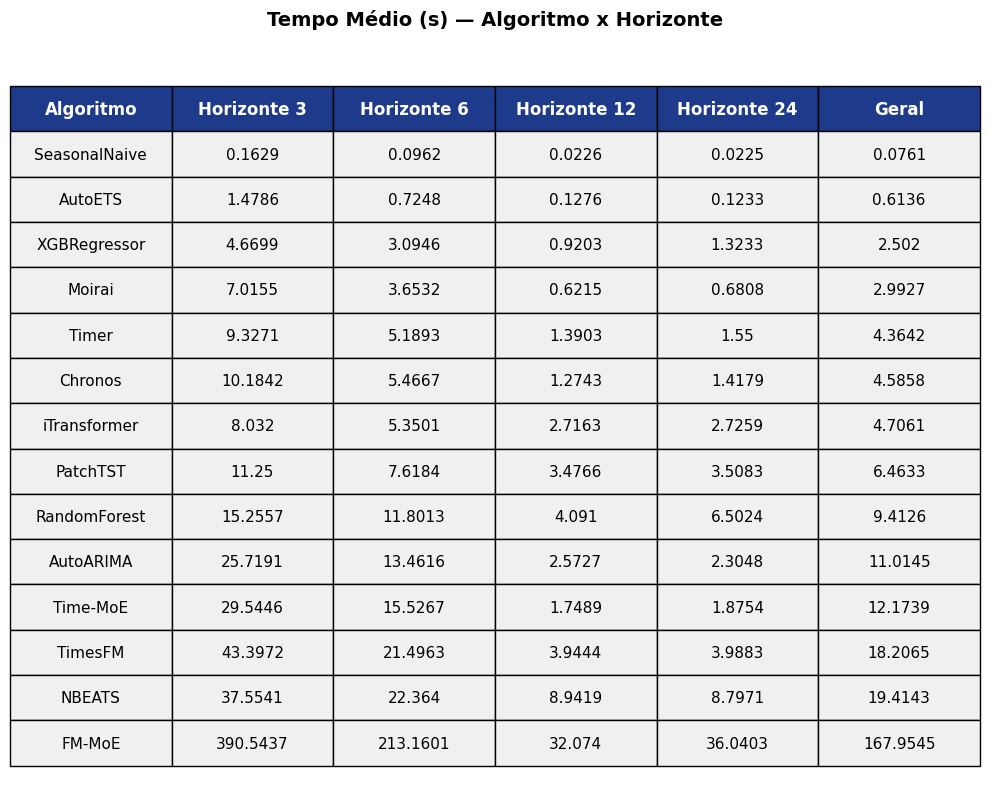

In [17]:
# ==========================================================
# PARTE 1 - TEMPO DE PROCESSAMENTO (ANP)
#
# Lê RESULTADOS_COMPLETOS_ANP/times_by_state_year/<experimento>/
#     <horizon_X>/times_<estado>_<ano>.csv
#
# Os tempos de horizontes diferentes vêm de execuções diferentes e a
# carga da máquina variou entre elas (horizon_3/horizon_6 do experimento
# ep_30 estão ~20x mais lentos para TODOS os modelos). Compare os
# algoritmos dentro de uma mesma coluna, não entre colunas.
# ==========================================================


def read_time_rows(horizon_path, horizon, exp_name):
    """Formato longo: 1 linha por (Modelo, Estado, Ano)."""

    rows = []

    for file in sorted(os.listdir(horizon_path)):

        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(horizon_path, file)
        state, year = parse_state_year(file)

        df = pd.read_csv(file_path)

        if "Modelo" not in df.columns:
            print(f"[WARNING] Coluna 'Modelo' ausente em {file_path}")
            continue

        time_col = next(
            (c for c in df.columns if c.lower().startswith("tempo")), None
        )

        if time_col is None:
            print(f"[WARNING] Coluna de tempo ausente em {file_path}")
            continue

        for _, row in df.iterrows():
            rows.append({
                "Algorithm": MODEL_NAME_MAP.get(row["Modelo"], row["Modelo"]),
                "Horizon": horizon,
                "State": state,
                "Year": year,
                "Time": row[time_col],
                "Experiment": exp_name
            })

    return rows


def load_times():

    rows = []

    for horizon, exp_name in horizons_to_process():

        horizon_path = os.path.join(TIMES_PATH, exp_name, horizon)

        if os.path.isdir(horizon_path):
            rows.extend(read_time_rows(horizon_path, horizon, exp_name))
        else:
            print(f"[WARNING] Tempos não encontrados: {horizon_path}")

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise SystemExit("\n[ERROR] Nenhum tempo carregado. Confira os caminhos.")

    df = (
        df
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Time"])
    )

    if IGNORE_MODELS:
        df = df[~df["Algorithm"].isin(IGNORE_MODELS)]

    return df


def load_reference_times(horizon):
    """Tempos do mesmo horizonte em TODOS os outros experimentos de
    TIMES_PATH (os baselines são os mesmos modelos em todos eles)."""

    rows = []

    for exp_name in sorted(os.listdir(TIMES_PATH)):

        horizon_path = os.path.join(TIMES_PATH, exp_name, horizon)

        if exp_name == BEST_EXPERIMENTS[horizon] or not os.path.isdir(horizon_path):
            continue

        rows.extend(read_time_rows(horizon_path, horizon, exp_name))

    return pd.DataFrame(rows)


def impute_time_outliers(df_times):
    """Substitui as medições estouradas por uma estimativa:

        tempo_estimado = tempo_ref(modelo) x carga(instância)

    tempo_ref é o tempo do mesmo modelo na mesma instância
    (Horizonte, Estado, Ano) em outro experimento em que ele NÃO estourou,
    e carga é a mediana geométrica da razão tempo_atual / tempo_ref dos
    demais modelos nessa instância — o que corrige a diferença de carga da
    máquina entre as execuções. O valor final é a mediana das estimativas
    obtidas com cada experimento de referência.

    O FM-MoE fica fora do cálculo da carga porque o tempo dele depende da
    configuração do experimento. Devolve df_times com a coluna Imputed."""

    df = df_times.assign(Imputed=False)

    is_out = (
        (df["Time"] > TIME_OUTLIER_THRESHOLD_S)
        & df["Algorithm"].isin(TIME_OUTLIER_MODELS)
    )

    if not is_out.any():
        print(f"\n[OK] Nenhuma medição acima de {TIME_OUTLIER_THRESHOLD_S} s "
              f"para {TIME_OUTLIER_MODELS}.")
        return df

    print(f"\n[INFO] {int(is_out.sum())} medição(ões) acima de "
          f"{TIME_OUTLIER_THRESHOLD_S} s serão estimadas:")

    print(
        df[is_out]
        .groupby(["Algorithm", "Horizon"])
        .agg(Linhas=("Time", "size"),
             Tempo_min=("Time", "min"),
             Tempo_max=("Time", "max"))
        .round(2)
        .to_string()
    )

    key = ["State", "Year"]
    load_models = sorted(
        set(df["Algorithm"]) - set(TIME_OUTLIER_MODELS) - {"FM-MoE"}
    )

    for horizon in df.loc[is_out, "Horizon"].unique():

        ref = (
            load_reference_times(horizon)
            .pivot_table(index=["Experiment"] + key, columns="Algorithm",
                         values="Time")
        )

        cur = (
            df[df["Horizon"] == horizon]
            .pivot_table(index=key, columns="Algorithm", values="Time")
            .reindex(ref.index.droplevel("Experiment"))
            .set_axis(ref.index, axis=0)
        )

        load = np.exp(
            np.log(cur[load_models] / ref[load_models])
            .replace([np.inf, -np.inf], np.nan)
            .median(axis=1)
        )

        for model in df.loc[is_out & (df["Horizon"] == horizon), "Algorithm"].unique():

            valid = ref[model] <= TIME_OUTLIER_THRESHOLD_S

            estimates = (ref[model] * load)[valid].dropna()
            estimate = estimates.groupby(level=key).median()
            n_refs = estimates.groupby(level=key).size()

            rows = is_out & (df["Horizon"] == horizon) & (df["Algorithm"] == model)
            instances = pd.MultiIndex.from_frame(df.loc[rows, key])

            df.loc[rows, "Time"] = estimate.reindex(instances).to_numpy()
            df.loc[rows, "Imputed"] = True

            print(f"[IMPUTADO] {model} {horizon}: {int(rows.sum())} medições | "
                  f"média estimada {df.loc[rows, 'Time'].mean():.4f} s | "
                  f"{int(n_refs.reindex(instances).min())} a "
                  f"{int(n_refs.reindex(instances).max())} experimentos de "
                  f"referência por instância")

    missing = df["Imputed"] & df["Time"].isna()

    if missing.any():
        print(f"[WARNING] {int(missing.sum())} medição(ões) sem referência "
              f"válida foram descartadas.")
        df = df[~missing]

    return df


# ==========================================================
# LOAD
# ==========================================================
df_times = load_times()

print(f"\n[INFO] Registros (Algoritmo x Estado x Ano x Horizonte): {len(df_times)}")
print(f"[INFO] Algoritmos ({df_times['Algorithm'].nunique()}): "
      f"{sorted(df_times['Algorithm'].unique())}")
print(f"[INFO] Horizontes: {sorted(df_times['Horizon'].unique())}")
print(f"[INFO] Estados: {df_times['State'].nunique()} | "
      f"Anos: {sorted(df_times['Year'].unique())}")


# ==========================================================
# CHECAGEM DE INTEGRIDADE (antes de descartar outliers)
# toda instância (Horizonte, Estado, Ano) precisa ter o mesmo conjunto
# de algoritmos, senão as médias usam quantidades diferentes de amostras
# ==========================================================
n_algorithms = df_times["Algorithm"].nunique()

instance_sizes = (
    df_times
    .groupby(["Horizon", "State", "Year"])["Algorithm"]
    .nunique()
)

if df_times.duplicated(subset=["Horizon", "State", "Year", "Algorithm"]).any():
    raise ValueError(
        "Há linhas duplicadas por (Horizonte, Estado, Ano, Algoritmo)."
    )

incompletas = instance_sizes[instance_sizes != n_algorithms]

if len(incompletas):
    print(f"\n[WARNING] {len(incompletas)} instâncias não têm os "
          f"{n_algorithms} algoritmos. Exemplos:")
    print(incompletas.head().to_string())
else:
    print(f"\n[OK] Todas as {len(instance_sizes)} instâncias "
          f"(horizonte x estado x ano) têm os {n_algorithms} algoritmos.")


# ==========================================================
# OUTLIERS DE TEMPO -> ESTIMATIVA
# ==========================================================
df_times = impute_time_outliers(df_times)

horizons = order_horizons(df_times["Horizon"].unique())


# ==========================================================
# MATRIZ Algoritmo x Horizonte (tempo médio)
# ==========================================================
mean_time_horizon = (
    df_times
    .groupby(["Algorithm", "Horizon"])["Time"]
    .mean()
    .reset_index()
)

mean_time_global = df_times.groupby("Algorithm")["Time"].mean()

plot_table(
    build_matrix(
        mean_time_horizon, "Algorithm", "Horizon", "Time",
        column_order=horizons,
        column_labels={h: horizon_label(h) for h in horizons},
        overall=mean_time_global,
        index_label="Algoritmo",
        ascending=True,
        decimals=4
    ),
    "Tempo Médio (s) — Algoritmo x Horizonte"
)

[INFO] horizon_3: 135 arquivos | 260 linhas por época | 0 log(s) com mais de um treino anexado (topk_2_norm_std_noise_True_ep_30_lr_0.001)
[INFO] horizon_6: 135 arquivos | 260 linhas por época | 0 log(s) com mais de um treino anexado (topk_2_norm_std_noise_True_ep_30_lr_0.001)
[INFO] horizon_12: 135 arquivos | 260 linhas por época | 135 log(s) com mais de um treino anexado (topk_2_norm_std_noise_True_ep_100_lr_0.001)
[WARNING] Mais de um valor de linhas/época encontrado: {260: 94, 263: 1}. Usando o mais frequente.
[INFO] horizon_24: 135 arquivos | 260 linhas por época | 132 log(s) com mais de um treino anexado (topk_2_norm_std_noise_True_ep_100_lr_0.001)

[INFO] Experts encontrados (5): ['Chronos', 'Moirai', 'Time-MoE', 'Timer', 'TimesFM']
[INFO] Horizontes: ['horizon_12', 'horizon_24', 'horizon_3', 'horizon_6']
[INFO] Estados: 27 | Anos: ['2020', '2021', '2022', '2023', '2024']
[INFO] Total de seleções contabilizadas: 6,094,400
[INFO] Linhas descartadas (treinos anexados + épocas inco

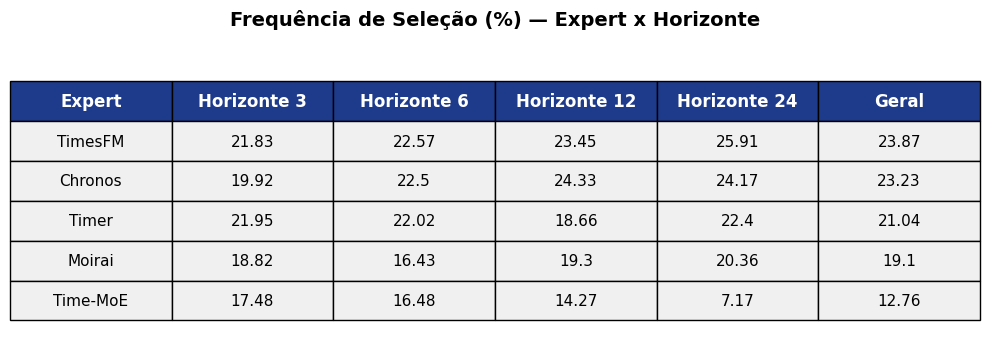

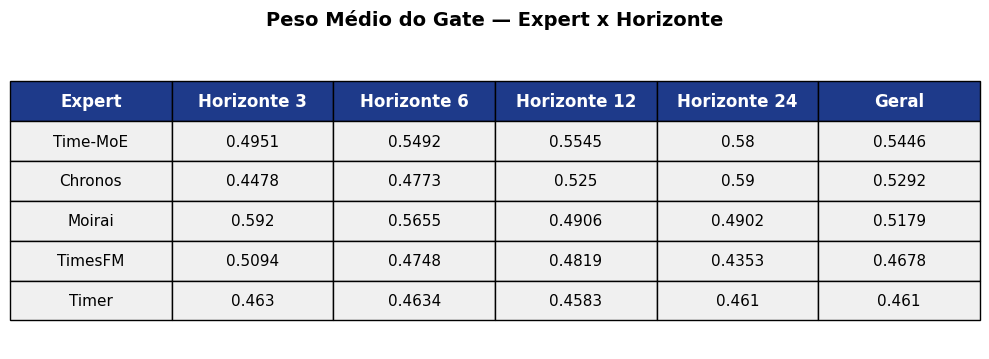

In [18]:
# ==========================================================
# PARTE 2 - PESOS E SELEÇÃO DOS EXPERTS (ANP)
#
# Lê RESULTADOS_COMPLETOS_ANP/trained_models/<experimento_sem_model_>/
#     <horizon_X>/excluding_<estado>/<...>_<ano>_log/experts_weights_train.csv
#
# Cada linha do CSV é um expert selecionado pelo gate em uma decisão de
# roteamento; com top-k = k, cada decisão gera k linhas.
#
# ATENÇÃO — LOGS COM MAIS DE UM TREINO ANEXADO
# Nos experimentos ep_100 (horizontes 12 e 24) o treino foi executado duas
# vezes gravando no MESMO diretório de log: o train_loss.csv tem o dobro
# das épocas e a coluna Epoch reinicia do 1 no meio do arquivo, e o
# experts_weights_train.csv tem as duas execuções concatenadas. Contar o
# arquivo inteiro dobraria as seleções desses horizontes. Por isso apenas
# UM treino por arquivo é considerado.
# ==========================================================


def find_expert_files(exp_dir_path, horizon):

    pattern = os.path.join(
        exp_dir_path, horizon, "excluding_*", "*_log", "experts_weights_train.csv"
    )

    return sorted(glob.glob(pattern))


def parse_expert_file_path(file_path):

    log_dir = os.path.basename(os.path.dirname(file_path))
    state_dir = os.path.basename(os.path.dirname(os.path.dirname(file_path)))

    state = state_dir.replace("excluding_", "")

    year_match = re.search(r"(19|20)\d{2}", log_dir)
    year = year_match.group(0) if year_match else "unknown"

    return state, year


def count_data_rows(file_path):
    """Conta as linhas de dados sem carregar o CSV na memória."""
    with open(file_path, "rb") as fh:
        return sum(1 for _ in fh) - 1


def read_epoch_column(log_dir):
    """Coluna Epoch do train_loss.csv do mesmo log."""
    loss_path = os.path.join(log_dir, "train_loss.csv")

    if not os.path.exists(loss_path):
        return None

    return pd.read_csv(loss_path, usecols=["Epoch"])["Epoch"].to_numpy()


def main_run_bounds(epochs):
    """Localiza o treino a ser contabilizado dentro de um log que pode ter
    mais de um treino anexado. Devolve (épocas a pular, épocas do treino,
    nº de treinos no arquivo).

    O train_loss.csv de um log com dois treinos anexados fica assim:
        Epoch = 1, 2, ..., 100, 1, 2, ..., 100
    então cada volta ao valor mínimo marca o início de um novo treino.

    O treino escolhido é o MAIS LONGO, não o último: em 38 logs do
    horizonte 24 a segunda execução foi abortada nas primeiras épocas
    (ex.: 76 épocas seguidas de 1), e ficar com ela jogaria fora o treino
    que de fato aconteceu. Em caso de empate — o caso do horizonte 12,
    onde os dois treinos têm o mesmo tamanho — fica com o último."""

    if len(epochs) == 0:
        return 0, 0, 0

    starts = list(np.flatnonzero(epochs == epochs.min())) + [len(epochs)]

    lengths = [starts[i + 1] - starts[i] for i in range(len(starts) - 1)]

    best = max(range(len(lengths)), key=lambda i: (lengths[i], i))

    return int(starts[best]), int(lengths[best]), len(lengths)


def infer_rows_per_epoch(files):
    """Linhas de peso gravadas por época. É uma constante do treino
    (top_k x nº de janelas de treino), então basta pegar o valor mais
    frequente entre os arquivos em que a divisão é exata."""

    candidates = collections.Counter()

    for file_path, n_rows, epochs in files:

        if epochs is None or len(epochs) == 0:
            continue

        if n_rows % len(epochs) == 0:
            candidates[n_rows // len(epochs)] += 1

    if not candidates:
        return None

    if len(candidates) > 1:
        print(f"[WARNING] Mais de um valor de linhas/época encontrado: "
              f"{dict(candidates)}. Usando o mais frequente.")

    return candidates.most_common(1)[0][0]


def aggregate_expert_file(file_path, n_rows, epochs, rows_per_epoch):
    """Nº de seleções e soma dos pesos por expert, considerando apenas o
    treino escolhido por main_run_bounds. Devolve (agg, info)."""

    if epochs is None or rows_per_epoch is None:
        epochs_used, n_runs, skip_rows = np.nan, 1, 0
        n_used = n_rows
    else:
        skipped_epochs, epochs_used, n_runs = main_run_bounds(epochs)
        skip_rows = skipped_epochs * rows_per_epoch
        # descarta também a época final incompleta, se houver
        n_used = epochs_used * rows_per_epoch

    df = pd.read_csv(file_path, usecols=["Learner", "Weight"])
    df = df.iloc[skip_rows:skip_rows + n_used]

    agg = (
        df
        .groupby("Learner")["Weight"]
        .agg(Selections="size", Weight_Sum="sum")
        .reset_index()
    )

    info = {
        "Rows_File": n_rows,
        "Rows_Used": len(df),
        "Epochs_Used": epochs_used,
        "Appended_Run": n_runs > 1
    }

    return agg, info


def load_experts():
    """Agrega arquivo a arquivo (são centenas de MB no total, então nada de
    concatenar tudo cru na memória).

    Passo 1: lê só os metadados (nº de linhas e a coluna Epoch) para
             descobrir as linhas por época e onde começa o treino válido.
    Passo 2: lê os pesos já recortando apenas esse treino."""

    partials = []
    run_info = []

    for horizon, exp_name in horizons_to_process():

        exp_dir = os.path.join(MODELS_PATH, experiment_dir_name(exp_name))

        files = find_expert_files(exp_dir, horizon)

        if not files:
            print(f"[WARNING] Nenhum experts_weights_train.csv em "
                  f"{os.path.join(exp_dir, horizon)}")
            continue

        # ---------- passo 1: metadados ----------
        meta = [
            (f, count_data_rows(f), read_epoch_column(os.path.dirname(f)))
            for f in files
        ]

        rows_per_epoch = infer_rows_per_epoch(meta)

        if rows_per_epoch is None:
            print(f"[WARNING] Não foi possível inferir as linhas por época em "
                  f"{horizon}; os arquivos serão usados por inteiro.")

        n_appended = sum(
            1 for _, _, e in meta if e is not None and main_run_bounds(e)[2] > 1
        )

        print(f"[INFO] {horizon}: {len(files)} arquivos | "
              f"{rows_per_epoch} linhas por época | "
              f"{n_appended} log(s) com mais de um treino anexado "
              f"({experiment_dir_name(exp_name)})")

        # ---------- passo 2: pesos do treino válido ----------
        for file_path, n_rows, epochs in meta:

            agg, info = aggregate_expert_file(
                file_path, n_rows, epochs, rows_per_epoch
            )

            run_info.append(info)

            if agg.empty:
                print(f"[WARNING] Nenhuma linha aproveitada em {file_path}")
                continue

            state, year = parse_expert_file_path(file_path)

            agg["Horizon"] = horizon
            agg["State"] = state
            agg["Year"] = year

            partials.append(agg)

    if not partials:
        raise SystemExit("\n[ERROR] Nenhum arquivo de pesos carregado.")

    return pd.concat(partials, ignore_index=True), pd.DataFrame(run_info)


def summarize_experts(df_experts, group_keys):
    """Frequência de seleção (%) e peso médio do gate por expert."""

    grouped = (
        df_experts
        .groupby(group_keys)
        .agg(
            Selections=("Selections", "sum"),
            Weight_Sum=("Weight_Sum", "sum")
        )
        .reset_index()
    )

    grouped["Mean_Weight"] = grouped["Weight_Sum"] / grouped["Selections"]

    scope_keys = [k for k in group_keys if k != "Learner"]

    if scope_keys:
        total_sel = grouped.groupby(scope_keys)["Selections"].transform("sum")
    else:
        total_sel = grouped["Selections"].sum()

    # % das seleções do gate que couberam a cada expert
    grouped["Selection_Pct"] = 100.0 * grouped["Selections"] / total_sel

    return grouped.drop(columns=["Weight_Sum"])


EXPERT_METRICS = [
    ("Selection_Pct", "Frequência de Seleção (%)", 2),
    ("Mean_Weight", "Peso Médio do Gate", 4)
]


# ==========================================================
# LOAD
# ==========================================================
df_experts, df_runs = load_experts()

print(f"\n[INFO] Experts encontrados ({df_experts['Learner'].nunique()}): "
      f"{sorted(df_experts['Learner'].unique())}")
print(f"[INFO] Horizontes: {sorted(df_experts['Horizon'].unique())}")
print(f"[INFO] Estados: {df_experts['State'].nunique()} | "
      f"Anos: {sorted(df_experts['Year'].unique())}")
print(f"[INFO] Total de seleções contabilizadas: "
      f"{int(df_experts['Selections'].sum()):,}")
print(f"[INFO] Linhas descartadas (treinos anexados + épocas incompletas): "
      f"{int(df_runs['Rows_File'].sum() - df_runs['Rows_Used'].sum()):,}")

horizons_exp = order_horizons(df_experts["Horizon"].unique())


# ==========================================================
# MATRIZES Expert x Horizonte
# ==========================================================
summary_horizon_exp = summarize_experts(df_experts, ["Learner", "Horizon"])
summary_global_exp = summarize_experts(df_experts, ["Learner"])

for value_col, label, decimals in EXPERT_METRICS:

    plot_table(
        build_matrix(
            summary_horizon_exp, "Learner", "Horizon", value_col,
            column_order=horizons_exp,
            column_labels={h: horizon_label(h) for h in horizons_exp},
            overall=summary_global_exp.set_index("Learner")[value_col],
            index_label="Expert",
            ascending=False,
            decimals=decimals
        ),
        f"{label} — Expert x Horizonte"
    )

[EXTRA] cif_2016_filtered: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] etth_filtered: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] hospital_filtered: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] m3_monthly_filtered: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] m4_monthly_filtered: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] nn5_weekly_filtered: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] tourism_monthly_filtered: modelos adicionados -> ['UniTS', 'SimMTM']

[INFO] Algoritmos (16): ['AutoARIMA', 'AutoETS', 'Chronos', 'FM-MoE', 'Moirai', 'NBEATS', 'PatchTST', 'RandomForest', 'SeasonalNaive', 'SimMTM', 'Time-MoE', 'Timer', 'TimesFM', 'UniTS', 'XGBRegressor', 'iTransformer']
[INFO] Datasets (7): ['cif_2016_filtered', 'etth_filtered', 'hospital_filtered', 'm3_monthly_filtered', 'm4_monthly_filtered', 'nn5_weekly_filtered', 'tourism_monthly_filtered']

[OK] Todos os 7 datasets têm os 16 algoritmos.


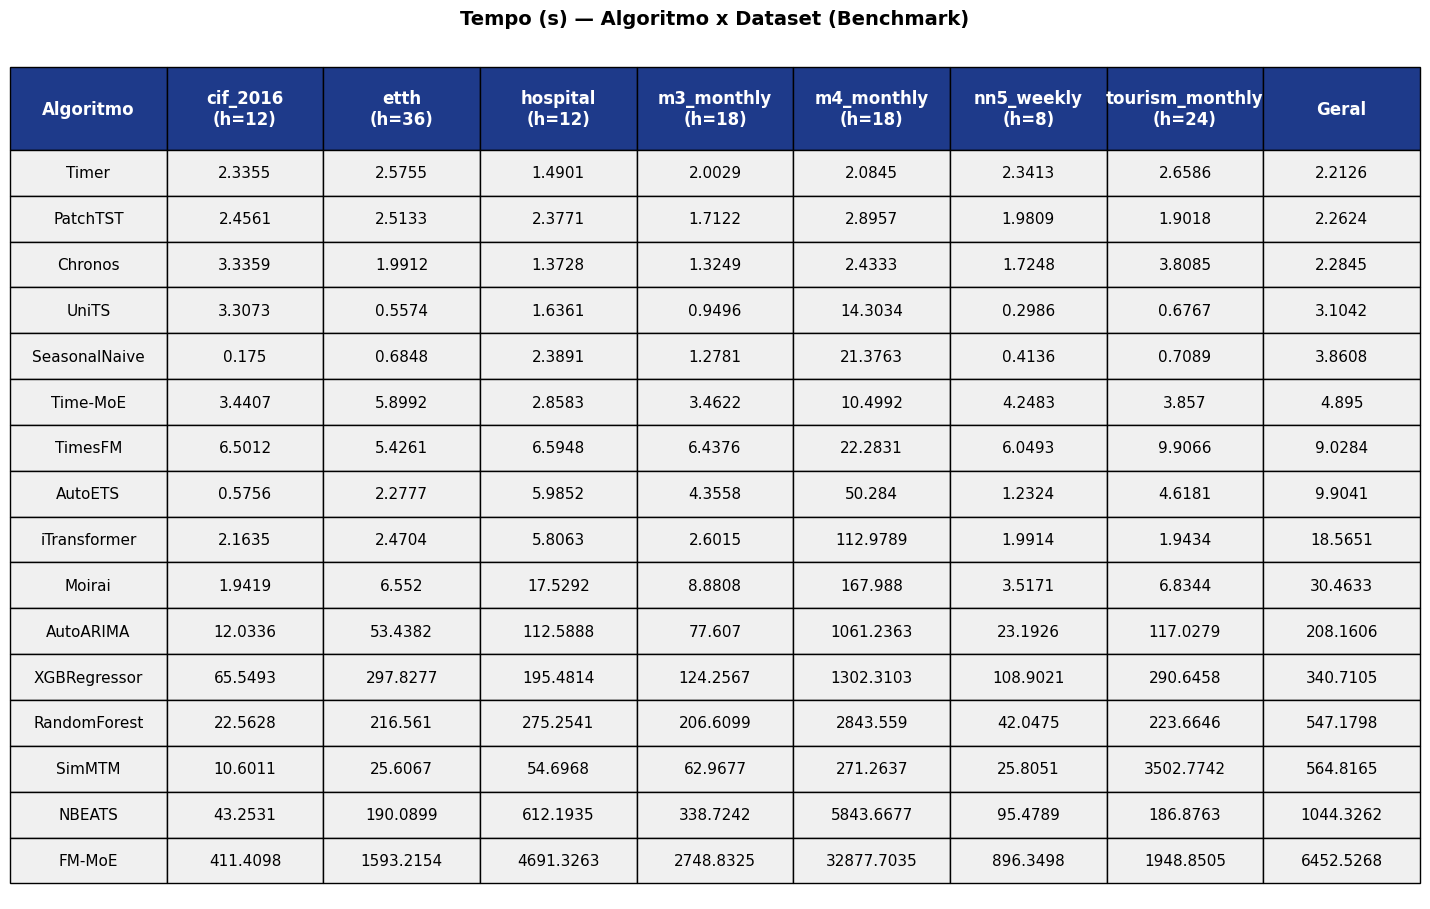

In [19]:
# ==========================================================
# PARTE 3 - TEMPO DE PROCESSAMENTO (BENCHMARK)
#
# Lê RESULTADOS_FINAIS_BENCHMARK/times_benchmark/<best_config>/
#     times_<dataset>.csv
# e anexa os modelos extras de times_benchmark/novos_models/.
#
# Há uma única medição por (Algoritmo, Dataset); a coluna "Geral" é a
# média simples entre os datasets.
# ==========================================================


def read_bench_times(file_path):

    df = pd.read_csv(file_path)

    time_col = next(c for c in df.columns if c.lower().startswith("tempo"))

    return pd.DataFrame({
        "Algorithm": df["Modelo"].map(lambda m: MODEL_NAME_MAP.get(m, m)),
        "Time": df[time_col]
    })


def load_bench_times():

    frames = []

    for dataset, info in DATASETS.items():

        file_path = os.path.join(
            BENCH_TIMES_PATH, info["best_config"], f"times_{dataset}.csv"
        )

        if not os.path.exists(file_path):
            print(f"[WARNING] Tempos não encontrados: {file_path}")
            continue

        df = read_bench_times(file_path)

        # Modelos extras (UniTS, SimMTM, ...): os já presentes no arquivo
        # original não são duplicados.
        extra_path = os.path.join(BENCH_EXTRA_TIMES_PATH, f"times_{dataset}.csv")

        if os.path.exists(extra_path):
            df_extra = read_bench_times(extra_path)
            df_extra = df_extra[~df_extra["Algorithm"].isin(df["Algorithm"])]

            if not df_extra.empty:
                print(f"[EXTRA] {dataset}: modelos adicionados -> "
                      f"{list(df_extra['Algorithm'])}")
                df = pd.concat([df, df_extra], ignore_index=True)

        df["Dataset"] = dataset
        frames.append(df)

    if not frames:
        raise SystemExit("\n[ERROR] Nenhum tempo de benchmark carregado.")

    df = (
        pd.concat(frames, ignore_index=True)
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Time"])
    )

    if IGNORE_MODELS:
        df = df[~df["Algorithm"].isin(IGNORE_MODELS)]

    return df


# ==========================================================
# LOAD
# ==========================================================
df_bench_times = load_bench_times()

datasets_bench = [d for d in DATASETS if d in set(df_bench_times["Dataset"])]

print(f"\n[INFO] Algoritmos ({df_bench_times['Algorithm'].nunique()}): "
      f"{sorted(df_bench_times['Algorithm'].unique())}")
print(f"[INFO] Datasets ({len(datasets_bench)}): {datasets_bench}")

# todo dataset precisa ter o mesmo conjunto de algoritmos, senão o "Geral"
# de cada algoritmo é a média de quantidades diferentes de datasets
n_bench_algorithms = df_bench_times["Algorithm"].nunique()
bench_sizes = df_bench_times.groupby("Dataset")["Algorithm"].nunique()
bench_incompletos = bench_sizes[bench_sizes != n_bench_algorithms]

if len(bench_incompletos):
    print(f"\n[WARNING] Datasets sem os {n_bench_algorithms} algoritmos:")
    print(bench_incompletos.to_string())
else:
    print(f"\n[OK] Todos os {len(bench_sizes)} datasets têm os "
          f"{n_bench_algorithms} algoritmos.")


# ==========================================================
# MATRIZ Algoritmo x Dataset (tempo)
# ==========================================================
plot_table(
    build_matrix(
        df_bench_times, "Algorithm", "Dataset", "Time",
        column_order=datasets_bench,
        column_labels={d: dataset_label(d) for d in datasets_bench},
        overall=df_bench_times.groupby("Algorithm")["Time"].mean(),
        index_label="Algoritmo",
        ascending=True,
        decimals=4
    ),
    "Tempo (s) — Algoritmo x Dataset (Benchmark)"
)

[INFO] cif_2016_filtered: 8,064 seleções | 84 épocas
[INFO] etth_filtered: 14,400 seleções | 36 épocas
[INFO] hospital_filtered: 92,040 seleções | 60 épocas
[INFO] m3_monthly_filtered: 20,880 seleções | 30 épocas
[INFO] m4_monthly_filtered: 402,180 seleções | 30 épocas
[INFO] nn5_weekly_filtered: 4,662 seleções | 21 épocas
[INFO] tourism_monthly_filtered: 13,104 seleções | 39 épocas

[INFO] Experts encontrados (5): ['Chronos', 'Moirai', 'Time-MoE', 'Timer', 'TimesFM']


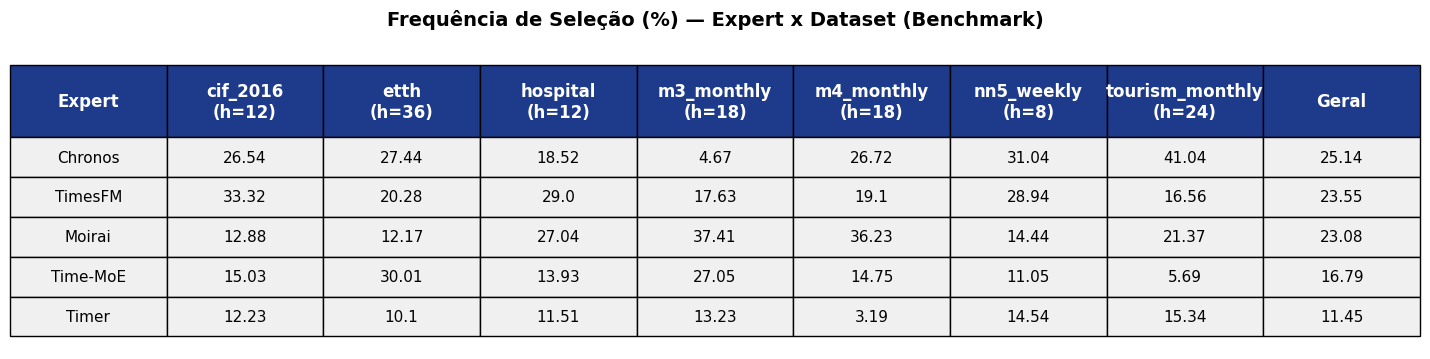

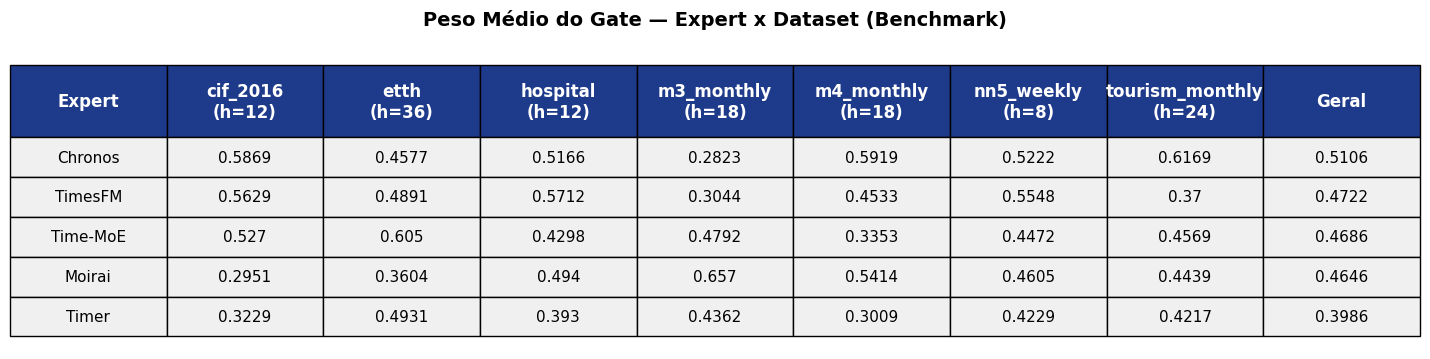

In [20]:
# ==========================================================
# PARTE 4 - PESOS E SELEÇÃO DOS EXPERTS (BENCHMARK)
#
# Lê RESULTADOS_COMPLETOS_BENCHMARK/trained_models_benchmark/<best_config>/
#     <dataset>/model_<best_config>_log/experts_weights_train.csv
#
# Mesmo tratamento de treinos anexados da Parte 2, mas as linhas por
# época são inferidas por arquivo, pois cada dataset tem o seu nº de
# janelas de treino.
#
# A coluna "Geral" é a média simples entre os datasets: o volume de
# seleções varia muito entre eles (o m4_monthly sozinho tem ~70% delas),
# então somar tudo faria o "Geral" refletir praticamente só o m4.
# ==========================================================


def bench_expert_file(dataset, config):
    return os.path.join(
        BENCH_MODELS_PATH, config, dataset, f"model_{config}_log",
        "experts_weights_train.csv"
    )


def load_bench_experts():

    partials = []

    for dataset, info in DATASETS.items():

        file_path = bench_expert_file(dataset, info["best_config"])

        if not os.path.exists(file_path):
            print(f"[WARNING] Pesos não encontrados: {file_path}")
            continue

        n_rows = count_data_rows(file_path)
        epochs = read_epoch_column(os.path.dirname(file_path))
        rows_per_epoch = infer_rows_per_epoch([(file_path, n_rows, epochs)])

        agg, run = aggregate_expert_file(file_path, n_rows, epochs, rows_per_epoch)

        print(f"[INFO] {dataset}: {run['Rows_Used']:,} seleções | "
              f"{run['Epochs_Used']} épocas"
              + (" | log com mais de um treino anexado" if run["Appended_Run"] else ""))

        if agg.empty:
            print(f"[WARNING] Nenhuma linha aproveitada em {file_path}")
            continue

        agg["Dataset"] = dataset
        partials.append(agg)

    if not partials:
        raise SystemExit("\n[ERROR] Nenhum arquivo de pesos de benchmark carregado.")

    return pd.concat(partials, ignore_index=True)


# ==========================================================
# LOAD
# ==========================================================
df_bench_experts = load_bench_experts()

datasets_bench_exp = [d for d in DATASETS if d in set(df_bench_experts["Dataset"])]

print(f"\n[INFO] Experts encontrados ({df_bench_experts['Learner'].nunique()}): "
      f"{sorted(df_bench_experts['Learner'].unique())}")


# ==========================================================
# MATRIZES Expert x Dataset
# ==========================================================
summary_dataset_exp = summarize_experts(df_bench_experts, ["Learner", "Dataset"])

for value_col, label, decimals in EXPERT_METRICS:

    plot_table(
        build_matrix(
            summary_dataset_exp, "Learner", "Dataset", value_col,
            column_order=datasets_bench_exp,
            column_labels={d: dataset_label(d) for d in datasets_bench_exp},
            overall=summary_dataset_exp.groupby("Learner")[value_col].mean(),
            index_label="Expert",
            ascending=False,
            decimals=decimals
        ),
        f"{label} — Expert x Dataset (Benchmark)"
    )